In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
!nvidia-smi

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Tue Sep  1 04:33:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |       

In [1]:
from google.colab import drive

drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

base_path = "/content/drive/MyDrive/DER01"

print("Contents of DER01:")
print(os.listdir(base_path))

Contents of DER01:
['raw_datasets', 'processed_dataset', 'models']


In [3]:
raw_path = os.path.join(base_path, "raw_datasets")

print("Contents of raw_datasets:")
print(os.listdir(raw_path))

Contents of raw_datasets:
['fire', 'flood', 'structural_damage']


In [4]:
for category in ["fire", "flood", "structural_damage"]:
    category_path = os.path.join(raw_path, category)

    print("\n==============================")
    print(category.upper())
    print("==============================")

    for item in os.listdir(category_path):
        print(item)


FIRE
fire(1).zip
fire(2).zip

FLOOD
flood(1).zip
flood(2).zip

STRUCTURAL_DAMAGE
structuraldamage(1).zip
structuraldamage(2).zip


In [5]:
import zipfile
import os

for category in ["fire", "flood", "structural_damage"]:
    category_path = os.path.join(raw_path, category)

    print("\n" + "=" * 50)
    print(category.upper())
    print("=" * 50)

    for filename in os.listdir(category_path):
        if filename.lower().endswith(".zip"):
            zip_path = os.path.join(category_path, filename)

            print(f"\n📦 {filename}")

            with zipfile.ZipFile(zip_path, "r") as z:
                files = z.namelist()

                print("Total files:", len(files))
                print("First 20 files:")

                for f in files[:20]:
                    print("  ", f)


FIRE

📦 fire(1).zip
Total files: 999
First 20 files:
   fire_dataset/fire_images/fire.1.png
   fire_dataset/fire_images/fire.10.png
   fire_dataset/fire_images/fire.100.png
   fire_dataset/fire_images/fire.101.png
   fire_dataset/fire_images/fire.102.png
   fire_dataset/fire_images/fire.103.png
   fire_dataset/fire_images/fire.104.png
   fire_dataset/fire_images/fire.105.png
   fire_dataset/fire_images/fire.106.png
   fire_dataset/fire_images/fire.107.png
   fire_dataset/fire_images/fire.108.png
   fire_dataset/fire_images/fire.109.png
   fire_dataset/fire_images/fire.11.png
   fire_dataset/fire_images/fire.110.png
   fire_dataset/fire_images/fire.111.png
   fire_dataset/fire_images/fire.112.png
   fire_dataset/fire_images/fire.113.png
   fire_dataset/fire_images/fire.114.png
   fire_dataset/fire_images/fire.115.png
   fire_dataset/fire_images/fire.116.png

📦 fire(2).zip
Total files: 15608
First 20 files:
   fire_dataset/fire/00159.jpg
   fire_dataset/fire/00160.jpg
   fire_dataset/fi

In [6]:
import zipfile
import os
from collections import Counter

image_extensions = (".jpg", ".jpeg", ".png", ".webp")

for category in ["fire", "flood", "structural_damage"]:
    category_path = os.path.join(raw_path, category)

    print("\n" + "=" * 60)
    print(category.upper())
    print("=" * 60)

    for filename in os.listdir(category_path):
        if filename.lower().endswith(".zip"):
            zip_path = os.path.join(category_path, filename)

            with zipfile.ZipFile(zip_path, "r") as z:
                image_files = [
                    f for f in z.namelist()
                    if f.lower().endswith(image_extensions)
                    and not f.endswith("/")
                ]

                print(f"\n📦 {filename}")
                print(f"Image files: {len(image_files)}")

                # Show image folders
                folders = Counter(
                    os.path.dirname(f) for f in image_files
                )

                print("Image folders:")
                for folder, count in folders.most_common(10):
                    print(f"  {folder or '[root]'} → {count}")


FIRE

📦 fire(1).zip
Image files: 999
Image folders:
  fire_dataset/fire_images → 755
  fire_dataset/non_fire_images → 244

📦 fire(2).zip
Image files: 15606
Image folders:
  fire_dataset/not_fire → 9755
  fire_dataset/fire → 5851

FLOOD

📦 flood(1).zip
Image files: 580
Image folders:
  Image → 290
  Mask → 290

📦 flood(2).zip
Image files: 6804
Image folders:
  Images → 3402
  Masks → 3402

STRUCTURAL_DAMAGE

📦 structuraldamage(1).zip
Image files: 2706
Image folders:
  2D_structural_damage_dataset-main/JPEGImages → 2706

📦 structuraldamage(2).zip
Image files: 290
Image folders:
  Dataset_CVAT/images/default → 290


In [9]:
import zipfile
import random
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

def show_samples(zip_path, folder_keyword, title, n=6):
    with zipfile.ZipFile(zip_path, "r") as z:
        files = [
            f for f in z.namelist()
            if folder_keyword in f.lower()
            and f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ]

        samples = random.sample(files, min(n, len(files)))

        plt.figure(figsize=(15, 8))

        for i, file in enumerate(samples):
            image_data = z.read(file)
            image = Image.open(BytesIO(image_data)).convert("RGB")

            plt.subplot(2, 3, i + 1)
            plt.imshow(image)
            plt.axis("off")

        plt.suptitle(title)
        plt.show()

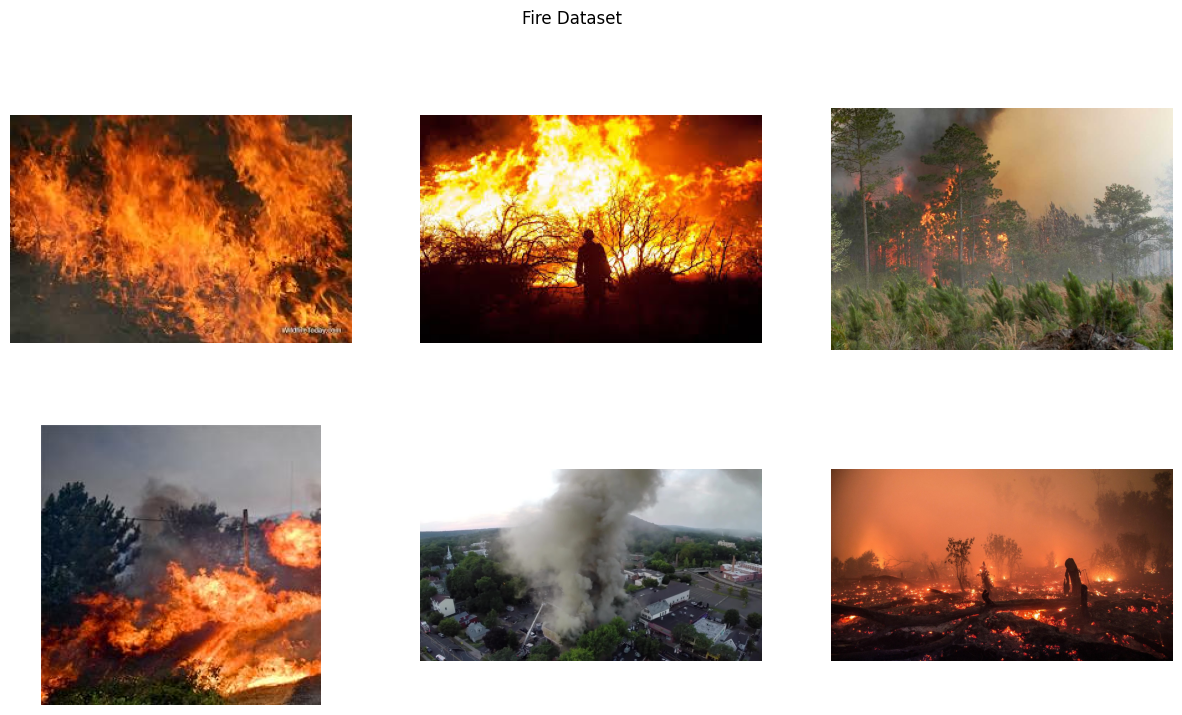

In [10]:
show_samples(
    "/content/drive/MyDrive/DER01/raw_datasets/fire/fire(2).zip",
    "/fire/",
    "Fire Dataset"
)

In [13]:
show_samples(
    "/content/drive/MyDrive/DER01/raw_datasets/flood/flood(2).zip",
    "/images/",
    "Flood Dataset"
)

<Figure size 1500x800 with 0 Axes>

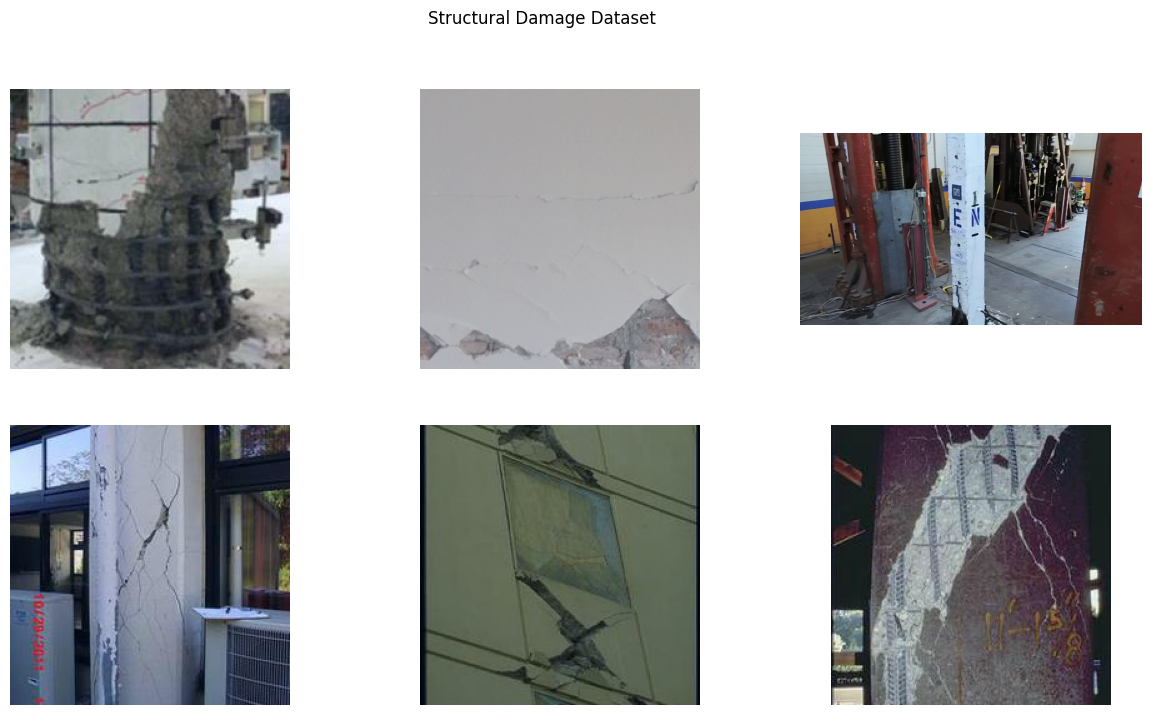

In [14]:
show_samples(
    "/content/drive/MyDrive/DER01/raw_datasets/structural_damage/structuraldamage(1).zip",
    "jpegimages/",
    "Structural Damage Dataset"
)

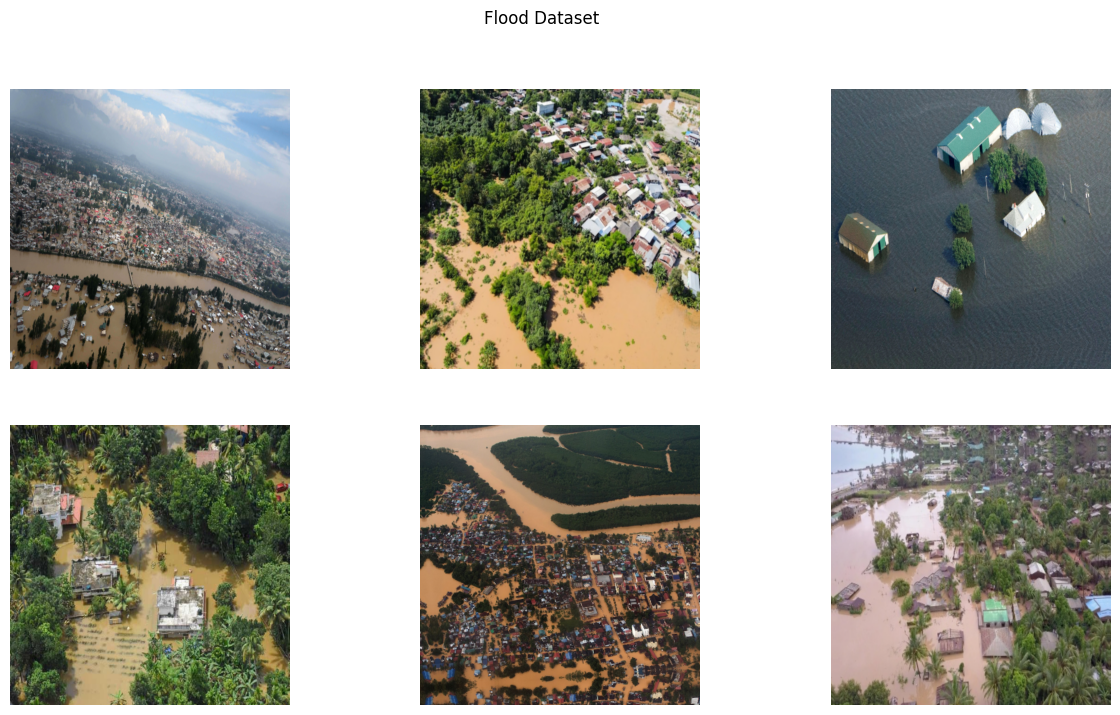

In [15]:
show_samples(
    "/content/drive/MyDrive/DER01/raw_datasets/flood/flood(2).zip",
    "images/",
    "Flood Dataset"
)

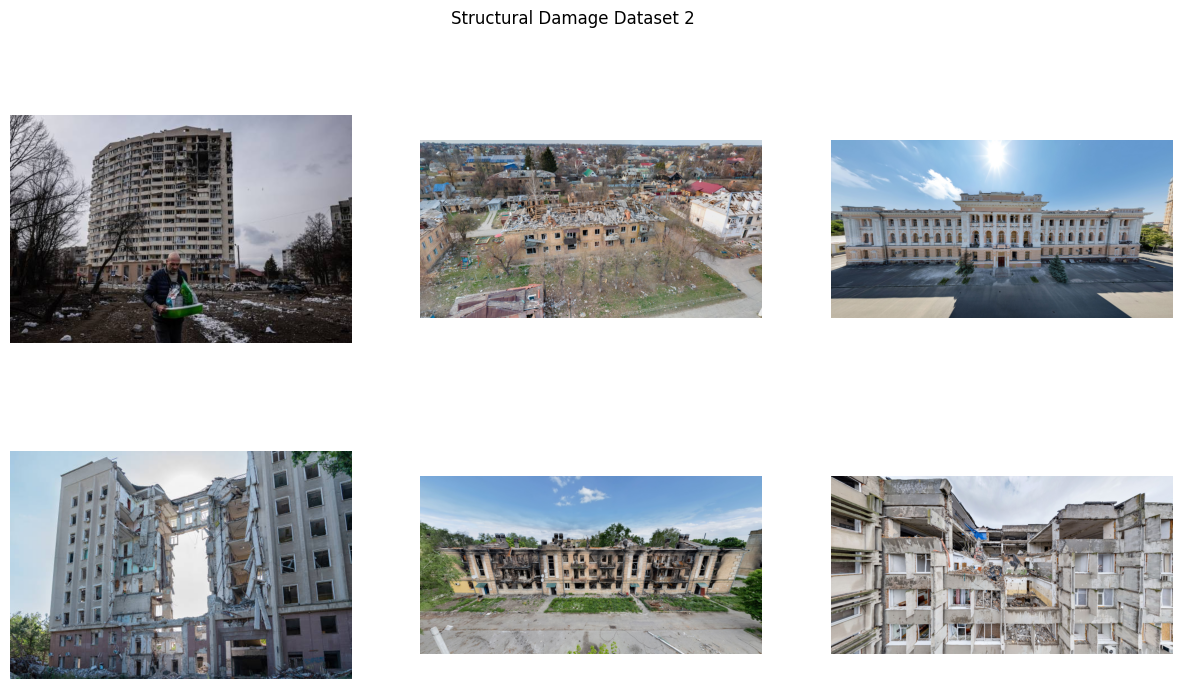

In [16]:
show_samples(
    "/content/drive/MyDrive/DER01/raw_datasets/structural_damage/structuraldamage(2).zip",
    "images/default/",
    "Structural Damage Dataset 2"
)

In [17]:
import os

processed_path = "/content/drive/MyDrive/DER01/processed_dataset"

for category in ["Fire", "Flood", "Structural_Damage"]:
    os.makedirs(
        os.path.join(processed_path, category),
        exist_ok=True
    )

print("Processed dataset folders created!")
print(os.listdir(processed_path))

Processed dataset folders created!
['Fire', 'Flood', 'Structural_Damage']


In [18]:
import zipfile
import os
import random
import shutil

fire_sources = [
    (
        "/content/drive/MyDrive/DER01/raw_datasets/fire/fire(1).zip",
        "fire_dataset/fire_images/"
    ),
    (
        "/content/drive/MyDrive/DER01/raw_datasets/fire/fire(2).zip",
        "fire_dataset/fire/"
    )
]

fire_files = []

for zip_path, folder in fire_sources:

    with zipfile.ZipFile(zip_path, "r") as z:

        files = [
            f for f in z.namelist()
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            and f.startswith(folder)
        ]

        fire_files.extend([
            (zip_path, f) for f in files
        ])

print("Total Fire images found:", len(fire_files))

random.seed(42)
random.shuffle(fire_files)

fire_files = fire_files[:3000]

print("Fire images selected:", len(fire_files))

fire_output = os.path.join(processed_path, "Fire")

for i, (zip_path, file_name) in enumerate(fire_files):

    with zipfile.ZipFile(zip_path, "r") as z:

        data = z.read(file_name)

    extension = os.path.splitext(file_name)[1]

    output_file = os.path.join(
        fire_output,
        f"fire_{i:05d}{extension}"
    )

    with open(output_file, "wb") as f:
        f.write(data)

print("Fire extraction complete!")

Total Fire images found: 6606
Fire images selected: 3000
Fire extraction complete!


In [19]:
flood_sources = [
    (
        "/content/drive/MyDrive/DER01/raw_datasets/flood/flood(1).zip",
        "Image/"
    ),
    (
        "/content/drive/MyDrive/DER01/raw_datasets/flood/flood(2).zip",
        "Images/"
    )
]

flood_files = []

for zip_path, folder in flood_sources:

    with zipfile.ZipFile(zip_path, "r") as z:

        files = [
            f for f in z.namelist()
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            and f.startswith(folder)
        ]

        flood_files.extend([
            (zip_path, f) for f in files
        ])

print("Total Flood images found:", len(flood_files))

random.seed(42)
random.shuffle(flood_files)

flood_files = flood_files[:3000]

print("Flood images selected:", len(flood_files))

flood_output = os.path.join(processed_path, "Flood")

for i, (zip_path, file_name) in enumerate(flood_files):

    with zipfile.ZipFile(zip_path, "r") as z:

        data = z.read(file_name)

    extension = os.path.splitext(file_name)[1]

    output_file = os.path.join(
        flood_output,
        f"flood_{i:05d}{extension}"
    )

    with open(output_file, "wb") as f:
        f.write(data)

print("Flood extraction complete!")

Total Flood images found: 3692
Flood images selected: 3000
Flood extraction complete!


In [20]:
damage_sources = [
    (
        "/content/drive/MyDrive/DER01/raw_datasets/structural_damage/structuraldamage(1).zip",
        "2D_structural_damage_dataset-main/JPEGImages/"
    ),
    (
        "/content/drive/MyDrive/DER01/raw_datasets/structural_damage/structuraldamage(2).zip",
        "Dataset_CVAT/images/default/"
    )
]

damage_files = []

for zip_path, folder in damage_sources:

    with zipfile.ZipFile(zip_path, "r") as z:

        files = [
            f for f in z.namelist()
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            and f.startswith(folder)
        ]

        damage_files.extend([
            (zip_path, f) for f in files
        ])

print("Total Structural Damage images found:", len(damage_files))

random.seed(42)
random.shuffle(damage_files)

print("Structural Damage images selected:", len(damage_files))

damage_output = os.path.join(
    processed_path,
    "Structural_Damage"
)

for i, (zip_path, file_name) in enumerate(damage_files):

    with zipfile.ZipFile(zip_path, "r") as z:

        data = z.read(file_name)

    extension = os.path.splitext(file_name)[1]

    output_file = os.path.join(
        damage_output,
        f"damage_{i:05d}{extension}"
    )

    with open(output_file, "wb") as f:
        f.write(data)

print("Structural Damage extraction complete!")

Total Structural Damage images found: 2996
Structural Damage images selected: 2996
Structural Damage extraction complete!


In [21]:
for category in ["Fire", "Flood", "Structural_Damage"]:

    folder = os.path.join(processed_path, category)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        )
    ]

    print(f"{category}: {len(images)} images")

Fire: 3000 images
Flood: 3000 images
Structural_Damage: 2996 images


In [22]:
from PIL import Image
import os

image_extensions = (".jpg", ".jpeg", ".png", ".webp")

bad_images = []
total_images = 0

for category in ["Fire", "Flood", "Structural_Damage"]:

    folder = os.path.join(processed_path, category)

    for filename in os.listdir(folder):

        if not filename.lower().endswith(image_extensions):
            continue

        total_images += 1

        filepath = os.path.join(folder, filename)

        try:
            with Image.open(filepath) as img:
                img.verify()

        except Exception as e:
            bad_images.append(filepath)

print("Total images checked:", total_images)
print("Corrupted images:", len(bad_images))

if bad_images:
    print("\nCorrupted files:")
    for image in bad_images[:20]:
        print(image)

Total images checked: 8996
Corrupted images: 1

Corrupted files:
/content/drive/MyDrive/DER01/processed_dataset/Flood/flood_01239.png


In [23]:
bad_file = "/content/drive/MyDrive/DER01/processed_dataset/Flood/flood_01239.png"

if os.path.exists(bad_file):
    os.remove(bad_file)
    print("Corrupted image removed.")
else:
    print("File not found.")

Corrupted image removed.


In [24]:
for category in ["Fire", "Flood", "Structural_Damage"]:
    folder = os.path.join(processed_path, category)

    count = sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    )

    print(f"{category}: {count}")

Fire: 3000
Flood: 2999
Structural_Damage: 2996


In [25]:
import os

split_path = "/content/drive/MyDrive/DER01/split_dataset"

for split in ["train", "val", "test"]:
    for category in ["Fire", "Flood", "Structural_Damage"]:
        os.makedirs(
            os.path.join(split_path, split, category),
            exist_ok=True
        )

print("Split folders created successfully!")

Split folders created successfully!


In [26]:
import os
import random
import shutil

random.seed(42)

categories = ["Fire", "Flood", "Structural_Damage"]

for category in categories:

    source_folder = os.path.join(processed_path, category)

    images = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    # Shuffle images
    random.shuffle(images)

    total = len(images)

    # 70% train, 15% validation, 15% test
    train_end = int(0.70 * total)
    val_end = int(0.85 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    print(f"\n{category}")
    print("Total:", total)
    print("Train:", len(train_images))
    print("Validation:", len(val_images))
    print("Test:", len(test_images))

    # Copy files
    for filename in train_images:
        shutil.copy2(
            os.path.join(source_folder, filename),
            os.path.join(split_path, "train", category, filename)
        )

    for filename in val_images:
        shutil.copy2(
            os.path.join(source_folder, filename),
            os.path.join(split_path, "val", category, filename)
        )

    for filename in test_images:
        shutil.copy2(
            os.path.join(source_folder, filename),
            os.path.join(split_path, "test", category, filename)
        )

print("\nDataset splitting complete!")


Fire
Total: 3000
Train: 2100
Validation: 450
Test: 450

Flood
Total: 2999
Train: 2099
Validation: 450
Test: 450

Structural_Damage
Total: 2996
Train: 2097
Validation: 449
Test: 450

Dataset splitting complete!


In [27]:
for split in ["train", "val", "test"]:

    print("\n" + "=" * 40)
    print(split.upper())
    print("=" * 40)

    for category in categories:

        folder = os.path.join(split_path, split, category)

        count = sum(
            1 for f in os.listdir(folder)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            )
        )

        print(f"{category}: {count}")


TRAIN
Fire: 2100
Flood: 2099
Structural_Damage: 2097

VAL
Fire: 450
Flood: 450
Structural_Damage: 449

TEST
Fire: 450
Flood: 450
Structural_Damage: 450


In [28]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [29]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [32]:
train_path = os.path.join(split_path, "train")
val_path = os.path.join(split_path, "val")
test_path = os.path.join(split_path, "test")

train_dataset = datasets.ImageFolder(
    train_path,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_path,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    test_path,
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))
print("Number of test images:", len(test_dataset))

Classes: ['Fire', 'Flood', 'Structural_Damage']
Number of training images: 6296
Number of validation images: 1349
Number of test images: 1350


In [33]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created!")

DataLoaders created!


In [34]:
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 85.5MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [35]:
num_classes = 3

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


In [36]:
# Freeze the pretrained EfficientNet layers

for param in model.features.parameters():
    param.requires_grad = False

# Keep our new classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print("Pretrained layers frozen.")
print("Classifier remains trainable.")

Pretrained layers frozen.
Classifier remains trainable.


In [37]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [38]:
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [39]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 4011391
Trainable parameters: 3843


In [40]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([2, 0, 2, 0, 2, 1, 2, 1, 2, 1])


In [41]:
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)
print("Output:", outputs[:2])

Output shape: torch.Size([32, 3])
Output: tensor([[ 0.0299,  0.1691,  0.1914],
        [-0.0071, -0.0554,  0.0174]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [42]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [43]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [44]:
num_epochs = 5

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/5] Train Loss: 0.2703 Train Acc: 0.9363 Val Loss: 0.0989 Val Acc: 0.9778
Epoch [2/5] Train Loss: 0.1005 Train Acc: 0.9743 Val Loss: 0.0652 Val Acc: 0.9844
Epoch [3/5] Train Loss: 0.0820 Train Acc: 0.9765 Val Loss: 0.0502 Val Acc: 0.9852
Epoch [4/5] Train Loss: 0.0770 Train Acc: 0.9779 Val Loss: 0.0449 Val Acc: 0.9874
Epoch [5/5] Train Loss: 0.0613 Train Acc: 0.9832 Val Loss: 0.0412 Val Acc: 0.9896


In [45]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss: 0.0404
Test Accuracy: 0.9867
Test Accuracy: 98.67%


In [46]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = test_dataset.classes

print("Classification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

print("Confusion Matrix:\n")

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

Classification Report:

                   precision    recall  f1-score   support

             Fire     0.9977    0.9756    0.9865       450
            Flood     0.9825    0.9956    0.9890       450
Structural_Damage     0.9802    0.9889    0.9845       450

         accuracy                         0.9867      1350
        macro avg     0.9868    0.9867    0.9867      1350
     weighted avg     0.9868    0.9867    0.9867      1350

Confusion Matrix:

[[439   4   7]
 [  0 448   2]
 [  1   4 445]]


In [47]:
from PIL import Image
import torch
import torch.nn.functional as F

def predict_image(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    image_tensor = val_test_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = F.softmax(outputs, dim=1)

        confidence, predicted_class = torch.max(
            probabilities, dim=1
        )

    predicted_class = predicted_class.item()
    confidence = confidence.item()

    class_name = class_names[predicted_class]

    print("Prediction:", class_name)
    print("Confidence:", f"{confidence * 100:.2f}%")

    return class_name, confidence

In [48]:
import random

test_fire_folder = os.path.join(
    split_path,
    "test",
    "Fire"
)

test_image = random.choice(
    os.listdir(test_fire_folder)
)

test_image_path = os.path.join(
    test_fire_folder,
    test_image
)

print("Testing:", test_image_path)

predict_image(test_image_path)

Testing: /content/drive/MyDrive/DER01/split_dataset/test/Fire/fire_02298.jpg
Prediction: Fire
Confidence: 99.81%


('Fire', 0.9981250166893005)

In [49]:
from google.colab import files

uploaded = files.upload()

Saving download (3).jpg to download (3).jpg


In [50]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Fire
Confidence: 99.81%


('Fire', 0.9980847835540771)

In [51]:
from google.colab import files

uploaded = files.upload()

Saving images.jpg to images.jpg


In [52]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Fire
Confidence: 100.00%


('Fire', 0.9999860525131226)

In [53]:
from google.colab import files

uploaded = files.upload()

Saving dc-Cover-n6hvnrjfa14mofsb1cblce2le3-20190110010939.Medi.jpeg to dc-Cover-n6hvnrjfa14mofsb1cblce2le3-20190110010939.Medi.jpeg


In [54]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Fire
Confidence: 100.00%


('Fire', 1.0)

In [55]:
from google.colab import files

uploaded = files.upload()

Saving images (1).jpg to images (1).jpg


In [56]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 55.13%


('Structural_Damage', 0.5513386726379395)

In [57]:
from google.colab import files

uploaded = files.upload()

Saving images (2).jpg to images (2).jpg


In [58]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Flood
Confidence: 78.84%


('Flood', 0.7884277701377869)

In [59]:
from google.colab import files

uploaded = files.upload()

Saving images (3).jpg to images (3).jpg


In [60]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 51.37%


('Structural_Damage', 0.5137441754341125)

In [61]:
from google.colab import files

uploaded = files.upload()

Saving images (4).jpg to images (4).jpg


In [62]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 99.96%


('Structural_Damage', 0.9995970129966736)

In [63]:
from google.colab import files

uploaded = files.upload()

Saving images (5).jpg to images (5).jpg


In [64]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 98.47%


('Structural_Damage', 0.9846602082252502)

In [65]:
from google.colab import files

uploaded = files.upload()

Saving images (6).jpg to images (6).jpg


In [66]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 86.62%


('Structural_Damage', 0.866157054901123)

In [67]:
import torch
import torch.nn.functional as F

def predict_with_probabilities(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    image_tensor = val_test_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)

        probabilities = F.softmax(outputs, dim=1)[0]

    print("Probabilities:")

    for name, prob in zip(class_names, probabilities):
        print(f"{name}: {prob.item() * 100:.2f}%")

    predicted_index = torch.argmax(probabilities).item()

    print("\nPrediction:", class_names[predicted_index])

In [68]:
predict_with_probabilities("YOUR_FLOOD_IMAGE_PATH")

FileNotFoundError: [Errno 2] No such file or directory: 'YOUR_FLOOD_IMAGE_PATH'

In [69]:
import torch
import torch.nn.functional as F

def predict_with_probabilities(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    image_tensor = val_test_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    print("Probabilities:")

    for name, prob in zip(class_names, probabilities):
        print(f"{name}: {prob.item() * 100:.2f}%")

    predicted_index = torch.argmax(probabilities).item()

    print("\nPrediction:", class_names[predicted_index])

In [70]:
uploaded = files.upload()

Saving images (6).jpg to images (6) (1).jpg


In [71]:
problematic_image = list(uploaded.keys())[0]

predict_with_probabilities(problematic_image)

Probabilities:
Fire: 10.66%
Flood: 2.73%
Structural_Damage: 86.62%

Prediction: Structural_Damage


In [72]:
problematic_image = list(uploaded.keys())[0]

predict_with_probabilities(problematic_image)

Probabilities:
Fire: 10.66%
Flood: 2.73%
Structural_Damage: 86.62%

Prediction: Structural_Damage


In [73]:
uploaded = files.upload()

Saving images (7).jpg to images (7).jpg


In [74]:
problematic_image = list(uploaded.keys())[0]

predict_with_probabilities(problematic_image)

Probabilities:
Fire: 7.03%
Flood: 11.11%
Structural_Damage: 81.86%

Prediction: Structural_Damage


In [75]:
from google.colab import files

uploaded = files.upload()

Saving images (7).jpg to images (7) (1).jpg


In [76]:
problematic_image = list(uploaded.keys())[0]

predict_with_probabilities(problematic_image)

Probabilities:
Fire: 7.03%
Flood: 11.11%
Structural_Damage: 81.86%

Prediction: Structural_Damage


In [77]:
from google.colab import files

uploaded = files.upload()

Saving images (8).jpg to images (8).jpg


In [78]:
problematic_image = list(uploaded.keys())[0]

predict_with_probabilities(problematic_image)

Probabilities:
Fire: 16.33%
Flood: 81.11%
Structural_Damage: 2.57%

Prediction: Flood


In [79]:
from google.colab import files

uploaded = files.upload()

Saving images (8).jpg to images (8) (1).jpg


In [80]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Flood
Confidence: 81.11%


('Flood', 0.8110634088516235)

In [81]:
from google.colab import files

uploaded = files.upload()

Saving images (1).jpg to images (1) (1).jpg


In [82]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 55.13%


('Structural_Damage', 0.5513386726379395)

In [83]:
from google.colab import files

uploaded = files.upload()

Saving dc-Cover-n6hvnrjfa14mofsb1cblce2le3-20190110010939.Medi.jpeg to dc-Cover-n6hvnrjfa14mofsb1cblce2le3-20190110010939.Medi (1).jpeg


In [84]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Fire
Confidence: 100.00%


('Fire', 1.0)

In [85]:
from google.colab import files

uploaded = files.upload()

Saving images (9).jpg to images (9).jpg


In [86]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 98.47%


('Structural_Damage', 0.9846602082252502)

In [87]:
from google.colab import files

uploaded = files.upload()

Saving 02int-asia-floods-photos-zlhw-mediumSquareAt3X.jpg to 02int-asia-floods-photos-zlhw-mediumSquareAt3X.jpg


In [88]:
uploaded_filename = list(uploaded.keys())[0]

predict_image(uploaded_filename)

Prediction: Structural_Damage
Confidence: 56.79%


('Structural_Damage', 0.5678615570068359)

In [89]:
from PIL import Image
import os
from collections import Counter

for category in ["Fire", "Flood", "Structural_Damage"]:

    folder = os.path.join(processed_path, category)

    sizes = Counter()

    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):

            filepath = os.path.join(folder, filename)

            try:
                with Image.open(filepath) as img:
                    sizes[img.size] += 1
            except:
                pass

    print("\n", category)
    print("Most common image sizes:")

    for size, count in sizes.most_common(5):
        print(size, "→", count)


 Fire
Most common image sizes:
(1920, 1080) → 487
(250, 250) → 450
(275, 183) → 89
(300, 168) → 75
(259, 194) → 52

 Flood
Most common image sizes:
(512, 512) → 2770
(1024, 682) → 7
(1200, 800) → 4
(620, 464) → 3
(1200, 675) → 3

 Structural_Damage
Most common image sizes:
(224, 224) → 1735
(256, 256) → 783
(1848, 966) → 247
(1280, 720) → 138
(3840, 2160) → 28


In [90]:
import os
import random
import pandas as pd

random.seed(42)

severity_samples = []

for category in ["Fire", "Flood", "Structural_Damage"]:

    folder = os.path.join(
        split_path,
        "train",
        category
    )

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        )
    ]

    # Randomly select 200 images
    selected = random.sample(images, 200)

    for filename in selected:
        severity_samples.append({
            "filename": filename,
            "category": category,
            "severity": ""
        })

severity_df = pd.DataFrame(severity_samples)

print("Total images selected:", len(severity_df))
print("\nImages per category:")
print(severity_df["category"].value_counts())

Total images selected: 600

Images per category:
category
Fire                 200
Flood                200
Structural_Damage    200
Name: count, dtype: int64


In [91]:
severity_csv = os.path.join(
    "/content/drive/MyDrive/DER01",
    "severity_labels.csv"
)

severity_df.to_csv(
    severity_csv,
    index=False
)

print("Severity labeling file created:")
print(severity_csv)

Severity labeling file created:
/content/drive/MyDrive/DER01/severity_labels.csv


In [92]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image

# Reload labels in case the notebook was restarted
severity_df = pd.read_csv(severity_csv)

# Find the next unlabeled image
current_index = 0

while (
    current_index < len(severity_df)
    and str(severity_df.loc[current_index, "severity"]).strip() != ""
    and str(severity_df.loc[current_index, "severity"]).lower() != "nan"
):
    current_index += 1


def show_current_image():

    global current_index

    clear_output(wait=True)

    if current_index >= len(severity_df):

        print("🎉 ALL IMAGES HAVE BEEN LABELED!")

        severity_df.to_csv(
            severity_csv,
            index=False
        )

        print("\nSaved to:")
        print(severity_csv)

        return

    row = severity_df.iloc[current_index]

    image_path = os.path.join(
        split_path,
        "train",
        row["category"],
        row["filename"]
    )

    print(f"Image {current_index + 1} / {len(severity_df)}")
    print(f"Category: {row['category']}")
    print(f"Filename: {row['filename']}")
    print()

    try:
        img = Image.open(image_path)
        img.thumbnail((700, 500))

        display(img)

    except Exception as e:
        print("Could not open image:", e)

    print("\nChoose severity:")

    display(button_box)


def save_label(label):

    global current_index

    severity_df.loc[
        current_index,
        "severity"
    ] = label

    # Save immediately so progress isn't lost
    severity_df.to_csv(
        severity_csv,
        index=False
    )

    current_index += 1

    show_current_image()


low_button = widgets.Button(
    description="LOW",
    button_style="success",
    layout=widgets.Layout(width="150px")
)

moderate_button = widgets.Button(
    description="MODERATE",
    button_style="warning",
    layout=widgets.Layout(width="150px")
)

high_button = widgets.Button(
    description="HIGH",
    button_style="danger",
    layout=widgets.Layout(width="150px")
)

skip_button = widgets.Button(
    description="SKIP",
    layout=widgets.Layout(width="150px")
)


low_button.on_click(
    lambda b: save_label("Low")
)

moderate_button.on_click(
    lambda b: save_label("Moderate")
)

high_button.on_click(
    lambda b: save_label("High")
)

skip_button.on_click(
    lambda b: save_label("Skip")
)


button_box = widgets.HBox([
    low_button,
    moderate_button,
    high_button,
    skip_button
])


show_current_image()

🎉 ALL IMAGES HAVE BEEN LABELED!

Saved to:
/content/drive/MyDrive/DER01/severity_labels.csv


In [93]:
import pandas as pd

severity_df = pd.read_csv(severity_csv)

print("Total rows:", len(severity_df))

print("\nSeverity distribution:")
print(severity_df["severity"].value_counts())

print("\nSeverity distribution by hazard:")
print(
    pd.crosstab(
        severity_df["category"],
        severity_df["severity"]
    )
)

Total rows: 600

Severity distribution:
severity
High        237
Moderate    173
Low         170
Skip         20
Name: count, dtype: int64

Severity distribution by hazard:
severity           High  Low  Moderate  Skip
category                                    
Fire                141    7        52     0
Flood                85   27        88     0
Structural_Damage    11  136        33    20


In [94]:
# Remove images whose severity could not be determined

severity_clean_df = severity_df[
    severity_df["severity"].isin(["Low", "Moderate", "High"])
].copy()

severity_clean_df = severity_clean_df.reset_index(drop=True)

print("Usable severity images:", len(severity_clean_df))

print("\nSeverity distribution:")
print(severity_clean_df["severity"].value_counts())

Usable severity images: 580

Severity distribution:
severity
High        237
Moderate    173
Low         170
Name: count, dtype: int64


In [95]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
severity_train_df, severity_temp_df = train_test_split(
    severity_clean_df,
    test_size=0.30,
    random_state=42,
    stratify=severity_clean_df["severity"]
)

# Second split: divide remaining 30% into 15% validation and 15% test
severity_val_df, severity_test_df = train_test_split(
    severity_temp_df,
    test_size=0.50,
    random_state=42,
    stratify=severity_temp_df["severity"]
)

print("Training:", len(severity_train_df))
print("Validation:", len(severity_val_df))
print("Test:", len(severity_test_df))

print("\nTraining distribution:")
print(severity_train_df["severity"].value_counts())

print("\nValidation distribution:")
print(severity_val_df["severity"].value_counts())

print("\nTest distribution:")
print(severity_test_df["severity"].value_counts())

Training: 406
Validation: 87
Test: 87

Training distribution:
severity
High        166
Moderate    121
Low         119
Name: count, dtype: int64

Validation distribution:
severity
High        36
Moderate    26
Low         25
Name: count, dtype: int64

Test distribution:
severity
High        35
Moderate    26
Low         26
Name: count, dtype: int64


In [96]:
severity_train_csv = "/content/drive/MyDrive/DER01/severity_train.csv"
severity_val_csv = "/content/drive/MyDrive/DER01/severity_val.csv"
severity_test_csv = "/content/drive/MyDrive/DER01/severity_test.csv"

severity_train_df.to_csv(severity_train_csv, index=False)
severity_val_df.to_csv(severity_val_csv, index=False)
severity_test_df.to_csv(severity_test_csv, index=False)

print("Severity split files saved successfully.")

Severity split files saved successfully.


In [97]:
from torch.utils.data import Dataset
from PIL import Image

severity_class_names = ["Low", "Moderate", "High"]

severity_class_to_idx = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}


class SeverityDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        category = row["category"]
        filename = row["filename"]

        image_path = os.path.join(
            split_path,
            "train",
            category,
            filename
        )

        image = Image.open(image_path).convert("RGB")

        label = severity_class_to_idx[
            row["severity"]
        ]

        if self.transform:
            image = self.transform(image)

        return image, label

In [98]:
severity_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

severity_val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [99]:
severity_train_dataset = SeverityDataset(
    severity_train_df,
    transform=severity_train_transform
)

severity_val_dataset = SeverityDataset(
    severity_val_df,
    transform=severity_val_test_transform
)

severity_test_dataset = SeverityDataset(
    severity_test_df,
    transform=severity_val_test_transform
)

print("Severity datasets created.")

print("Train:", len(severity_train_dataset))
print("Validation:", len(severity_val_dataset))
print("Test:", len(severity_test_dataset))

Severity datasets created.
Train: 406
Validation: 87
Test: 87


In [100]:
severity_train_loader = DataLoader(
    severity_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

severity_val_loader = DataLoader(
    severity_val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

severity_test_loader = DataLoader(
    severity_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Severity DataLoaders created.")

Severity DataLoaders created.


In [101]:
severity_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Replace the final classifier
severity_model.classifier[1] = nn.Linear(
    severity_model.classifier[1].in_features,
    3
)

severity_model = severity_model.to(device)

print(severity_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


In [102]:
for param in severity_model.features.parameters():
    param.requires_grad = False

for param in severity_model.classifier.parameters():
    param.requires_grad = True

print("Severity model pretrained features frozen.")
print("Severity classifier trainable.")

Severity model pretrained features frozen.
Severity classifier trainable.


In [103]:
import numpy as np
import torch

severity_counts = severity_train_df["severity"].value_counts()

print("Training counts:")
print(severity_counts)

total_samples = len(severity_train_df)
num_classes = 3

class_weights = []

for class_name in severity_class_names:

    count = severity_counts[class_name]

    weight = total_samples / (
        num_classes * count
    )

    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")
for name, weight in zip(
    severity_class_names,
    class_weights
):
    print(f"{name}: {weight.item():.4f}")

Training counts:
severity
High        166
Moderate    121
Low         119
Name: count, dtype: int64

Class weights:
Low: 1.1373
Moderate: 1.1185
High: 0.8153


In [104]:
severity_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

severity_optimizer = torch.optim.Adam(
    severity_model.classifier.parameters(),
    lr=0.001
)

print("Severity loss:", severity_criterion)
print("Severity optimizer:", severity_optimizer)

Severity loss: CrossEntropyLoss()
Severity optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [105]:
def train_severity_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [106]:
def validate_severity(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [107]:
num_severity_epochs = 10

for epoch in range(num_severity_epochs):

    train_loss, train_acc = train_severity_one_epoch(
        severity_model,
        severity_train_loader,
        severity_criterion,
        severity_optimizer,
        device
    )

    val_loss, val_acc = validate_severity(
        severity_model,
        severity_val_loader,
        severity_criterion,
        device
    )

    print(
        f"Epoch [{epoch+1}/{num_severity_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] Train Loss: 1.0337 Train Acc: 0.4901 Val Loss: 0.8841 Val Acc: 0.5977
Epoch [2/10] Train Loss: 0.8397 Train Acc: 0.6232 Val Loss: 0.7940 Val Acc: 0.6667
Epoch [3/10] Train Loss: 0.7868 Train Acc: 0.6675 Val Loss: 0.7734 Val Acc: 0.6437
Epoch [4/10] Train Loss: 0.7285 Train Acc: 0.6921 Val Loss: 0.7557 Val Acc: 0.6667
Epoch [5/10] Train Loss: 0.6964 Train Acc: 0.7315 Val Loss: 0.7297 Val Acc: 0.7126
Epoch [6/10] Train Loss: 0.6510 Train Acc: 0.7044 Val Loss: 0.6958 Val Acc: 0.6782
Epoch [7/10] Train Loss: 0.6328 Train Acc: 0.7118 Val Loss: 0.6873 Val Acc: 0.7011
Epoch [8/10] Train Loss: 0.6346 Train Acc: 0.7340 Val Loss: 0.6785 Val Acc: 0.6667
Epoch [9/10] Train Loss: 0.6404 Train Acc: 0.7340 Val Loss: 0.6807 Val Acc: 0.7241
Epoch [10/10] Train Loss: 0.6173 Train Acc: 0.7635 Val Loss: 0.6707 Val Acc: 0.6782


In [108]:
severity_test_loss, severity_test_acc = validate_severity(
    severity_model,
    severity_test_loader,
    severity_criterion,
    device
)

print(f"Severity Test Loss: {severity_test_loss:.4f}")
print(f"Severity Test Accuracy: {severity_test_acc:.4f}")
print(f"Severity Test Accuracy: {severity_test_acc * 100:.2f}%")


Severity Test Loss: 0.6756
Severity Test Accuracy: 0.7241
Severity Test Accuracy: 72.41%


In [109]:
from sklearn.metrics import classification_report, confusion_matrix

severity_model.eval()

all_severity_predictions = []
all_severity_labels = []

with torch.no_grad():

    for images, labels in severity_test_loader:

        images = images.to(device)

        outputs = severity_model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_severity_predictions.extend(
            predictions.cpu().numpy()
        )

        all_severity_labels.extend(
            labels.numpy()
        )

print("Severity Classification Report:\n")

print(
    classification_report(
        all_severity_labels,
        all_severity_predictions,
        target_names=severity_class_names,
        digits=4
    )
)

print("Severity Confusion Matrix:\n")

severity_cm = confusion_matrix(
    all_severity_labels,
    all_severity_predictions
)

print(severity_cm)

Severity Classification Report:

              precision    recall  f1-score   support

         Low     0.8000    0.7692    0.7843        26
    Moderate     0.5926    0.6154    0.6038        26
        High     0.7714    0.7714    0.7714        35

    accuracy                         0.7241        87
   macro avg     0.7213    0.7187    0.7198        87
weighted avg     0.7265    0.7241    0.7252        87

Severity Confusion Matrix:

[[20  4  2]
 [ 4 16  6]
 [ 1  7 27]]


In [110]:
def predict_disaster(image_path):

    # =========================
    # 1. HAZARD PREDICTION
    # =========================

    model.eval()

    image = Image.open(image_path).convert("RGB")

    hazard_tensor = val_test_transform(image)
    hazard_tensor = hazard_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        hazard_outputs = model(hazard_tensor)

        hazard_probs = F.softmax(
            hazard_outputs,
            dim=1
        )[0]

        hazard_confidence, hazard_index = torch.max(
            hazard_probs,
            dim=0
        )

    hazard = class_names[hazard_index.item()]

    # =========================
    # 2. SEVERITY PREDICTION
    # =========================

    severity_model.eval()

    severity_tensor = severity_val_test_transform(image)
    severity_tensor = severity_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        severity_outputs = severity_model(
            severity_tensor
        )

        severity_probs = F.softmax(
            severity_outputs,
            dim=1
        )[0]

        severity_confidence, severity_index = torch.max(
            severity_probs,
            dim=0
        )

    severity = severity_class_names[
        severity_index.item()
    ]

    # =========================
    # 3. FINAL RESULT
    # =========================

    result = {
        "hazard": hazard,
        "confidence": round(
            hazard_confidence.item(),
            4
        ),
        "severity": severity,
        "severity_confidence": round(
            severity_confidence.item(),
            4
        )
    }

    return result

In [111]:
from google.colab import files

# Open file chooser
uploaded = files.upload()

# Get the selected image path
image_path = next(iter(uploaded))

print("Selected image:", image_path)

# Pass the selected image to your existing function
result = predict_disaster(image_path)

print("\n========== PREDICTION ==========")
print("Hazard:", result["hazard"])
print("Hazard Confidence:", f'{result["confidence"] * 100:.2f}%')
print("Severity:", result["severity"])
print("Severity Confidence:", f'{result["severity_confidence"] * 100:.2f}%')
print("================================")

Saving dc-Cover-n6hvnrjfa14mofsb1cblce2le3-20190110010939.Medi.jpeg to dc-Cover-n6hvnrjfa14mofsb1cblce2le3-20190110010939.Medi (2).jpeg
Selected image: dc-Cover-n6hvnrjfa14mofsb1cblce2le3-20190110010939.Medi (2).jpeg

========== PREDICTION ==========
Hazard: Fire
Hazard Confidence: 100.00%
Severity: High
Severity Confidence: 72.04%


In [112]:
from google.colab import files

# Open file chooser
uploaded = files.upload()

# Get the selected image path
image_path = next(iter(uploaded))

print("Selected image:", image_path)

# Pass the selected image to your existing function
result = predict_disaster(image_path)

print("\n========== PREDICTION ==========")
print("Hazard:", result["hazard"])
print("Hazard Confidence:", f'{result["confidence"] * 100:.2f}%')
print("Severity:", result["severity"])
print("Severity Confidence:", f'{result["severity_confidence"] * 100:.2f}%')
print("================================")

Saving images (10).jpg to images (10).jpg
Selected image: images (10).jpg

========== PREDICTION ==========
Hazard: Flood
Hazard Confidence: 59.61%
Severity: High
Severity Confidence: 76.39%


In [113]:
from google.colab import files

# Open file chooser
uploaded = files.upload()

# Get the selected image path
image_path = next(iter(uploaded))

print("Selected image:", image_path)

# Pass the selected image to your existing function
result = predict_disaster(image_path)

print("\n========== PREDICTION ==========")
print("Hazard:", result["hazard"])
print("Hazard Confidence:", f'{result["confidence"] * 100:.2f}%')
print("Severity:", result["severity"])
print("Severity Confidence:", f'{result["severity_confidence"] * 100:.2f}%')
print("================================")

Saving images (11).jpg to images (11).jpg
Selected image: images (11).jpg

========== PREDICTION ==========
Hazard: Structural_Damage
Hazard Confidence: 88.48%
Severity: Low
Severity Confidence: 39.73%


In [114]:
import os

models_path = "/content/drive/MyDrive/DER01/models"

os.makedirs(models_path, exist_ok=True)

print("Models folder:", models_path)

Models folder: /content/drive/MyDrive/DER01/models


In [115]:
import os

models_path = "/content/drive/MyDrive/DER01/models"

os.makedirs(models_path, exist_ok=True)

print("Models folder:", models_path)

Models folder: /content/drive/MyDrive/DER01/models


In [116]:
hazard_model_path = os.path.join(
    models_path,
    "hazard_model.pth"
)

torch.save(
    model.state_dict(),
    hazard_model_path
)

print("Hazard model saved!")
print(hazard_model_path)

Hazard model saved!
/content/drive/MyDrive/DER01/models/hazard_model.pth


In [117]:
severity_model_path = os.path.join(
    models_path,
    "severity_model.pth"
)

torch.save(
    severity_model.state_dict(),
    severity_model_path
)

print("Severity model saved!")
print(severity_model_path)

Severity model saved!
/content/drive/MyDrive/DER01/models/severity_model.pth


In [118]:
print("Model files:")

for filename in os.listdir(models_path):
    filepath = os.path.join(models_path, filename)

    size_mb = os.path.getsize(filepath) / (1024 * 1024)

    print(f"{filename} → {size_mb:.2f} MB")

Model files:
hazard_model.pth → 15.59 MB
severity_model.pth → 15.59 MB


In [119]:
import json

model_config = {
    "architecture": "EfficientNet-B0",
    "input_size": [224, 224],

    "hazard_classes": [
        "Fire",
        "Flood",
        "Structural_Damage"
    ],

    "severity_classes": [
        "Low",
        "Moderate",
        "High"
    ],

    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225]
    }
}

config_path = os.path.join(
    models_path,
    "model_config.json"
)

with open(config_path, "w") as f:
    json.dump(model_config, f, indent=4)

print("Configuration saved!")

Configuration saved!


In [120]:
from torchvision import models
import torch
import torch.nn as nn

# Recreate hazard model architecture
loaded_hazard_model = models.efficientnet_b0(
    weights=None
)

loaded_hazard_model.classifier[1] = nn.Linear(
    loaded_hazard_model.classifier[1].in_features,
    3
)

loaded_hazard_model.load_state_dict(
    torch.load(
        hazard_model_path,
        map_location=device
    )
)

loaded_hazard_model = loaded_hazard_model.to(device)
loaded_hazard_model.eval()

print("Hazard model loaded successfully!")

Hazard model loaded successfully!


In [121]:
loaded_severity_model = models.efficientnet_b0(
    weights=None
)

loaded_severity_model.classifier[1] = nn.Linear(
    loaded_severity_model.classifier[1].in_features,
    3
)

loaded_severity_model.load_state_dict(
    torch.load(
        severity_model_path,
        map_location=device
    )
)

loaded_severity_model = loaded_severity_model.to(device)
loaded_severity_model.eval()

print("Severity model loaded successfully!")

Severity model loaded successfully!


In [122]:
!pip install fastapi uvicorn python-multipart pyngrok -q

In [123]:
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
import io

app = FastAPI(
    title="DER-01 Disaster Classification API",
    description="Fire, Flood and Structural Damage classification with severity estimation",
    version="1.0"
)

# Allow requests from the Node.js backend
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

print("FastAPI application created!")

FastAPI application created!


In [124]:
@app.post("/predict")
async def predict(
    image: UploadFile = File(...)
):

    try:
        # Read uploaded image
        image_bytes = await image.read()

        # Convert bytes to PIL image
        pil_image = Image.open(
            io.BytesIO(image_bytes)
        ).convert("RGB")

        # =================================
        # HAZARD PREDICTION
        # =================================

        model.eval()

        hazard_tensor = val_test_transform(
            pil_image
        )

        hazard_tensor = hazard_tensor.unsqueeze(0).to(device)

        with torch.no_grad():

            hazard_outputs = model(
                hazard_tensor
            )

            hazard_probs = F.softmax(
                hazard_outputs,
                dim=1
            )[0]

            hazard_confidence, hazard_index = torch.max(
                hazard_probs,
                dim=0
            )

        hazard = class_names[
            hazard_index.item()
        ]

        # =================================
        # SEVERITY PREDICTION
        # =================================

        severity_model.eval()

        severity_tensor = severity_val_test_transform(
            pil_image
        )

        severity_tensor = severity_tensor.unsqueeze(0).to(device)

        with torch.no_grad():

            severity_outputs = severity_model(
                severity_tensor
            )

            severity_probs = F.softmax(
                severity_outputs,
                dim=1
            )[0]

            severity_confidence, severity_index = torch.max(
                severity_probs,
                dim=0
            )

        severity = severity_class_names[
            severity_index.item()
        ]

        # =================================
        # RESPONSE
        # =================================

        return {
            "success": True,
            "hazard": hazard,
            "confidence": round(
                hazard_confidence.item(),
                4
            ),
            "severity": severity,
            "severity_confidence": round(
                severity_confidence.item(),
                4
            )
        }

    except Exception as e:

        return {
            "success": False,
            "error": str(e)
        }

In [125]:
import threading
import uvicorn

def run_api():
    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )

api_thread = threading.Thread(
    target=run_api,
    daemon=True
)

api_thread.start()

print("FastAPI server started on port 8000")

FastAPI server started on port 8000


In [126]:
from google.colab import files

uploaded = files.upload()

test_filename = next(iter(uploaded))

print("Testing:", test_filename)

Saving images (10).jpg to images (10) (1).jpg
Testing: images (10) (1).jpg


In [127]:
import requests

with open(test_filename, "rb") as f:

    response = requests.post(
        "http://127.0.0.1:8000/predict",
        files={
            "image": (
                test_filename,
                f,
                "image/jpeg"
            )
        }
    )

print("Status code:", response.status_code)
print("Response:")
print(response.json())

INFO:     127.0.0.1:51392 - "POST /predict HTTP/1.1" 200 OK
Status code: 200
Response:
{'success': True, 'hazard': 'Flood', 'confidence': 0.5961, 'severity': 'High', 'severity_confidence': 0.7639}


In [128]:
from pyngrok import ngrok

ngrok.set_auth_token("3IjpyypE2EopDqa1Zi36HuV2UXs_5HtR5hBJpZzpWnbTySvYb")

In [129]:
public_url = ngrok.connect(8000)

print("Public API URL:")
print(public_url)

Public API URL:
NgrokTunnel: "https://balance-possible-silicon.ngrok-free.dev" -> "http://localhost:8000"


In [130]:
import requests

url = "https://balance-possible-silicon.ngrok-free.dev/predict"

response = requests.get(url)

print("Status:", response.status_code)
print("Response:", response.text)

INFO:     8.228.24.184:0 - "GET /predict HTTP/1.1" 405 Method Not Allowed
Status: 405
Response: {"detail":"Method Not Allowed"}


In [131]:
uvicorn.run(app, host="0.0.0.0", port=8000)

RuntimeError: asyncio.run() cannot be called from a running event loop